# Install & Import Library

In [1]:
!pip install gensim nltk tensorflow scikit-learn

import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

from gensim.models import KeyedVectors
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.0 MB/s eta 0:00:00


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset + Split Train/Val/Test :

In [3]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1445 207 414


# Load FastText Embedding

In [4]:
from gensim.models import KeyedVectors

# Path file .kv hasil convert
save_path = "/content/drive/MyDrive/DistilBERT-7-Mei/fasttext_id.kv"

# Load cepat
w2v = KeyedVectors.load(save_path, mmap='r')

embedding_dim = w2v.vector_size

print("Embedding dim:", embedding_dim)
print("Jumlah kata:", len(w2v))


Embedding dim: 300
Jumlah kata: 2000000


# Build Vocabulary (Menggunakan nltk.word_tokenize)

In [5]:
def build_vocab(texts):
    vocab = {}
    idx = 1  # 0 untuk PAD

    for txt in texts:
        for tok in word_tokenize(txt):
            if tok not in vocab:
                vocab[tok] = idx
                idx += 1
    return vocab

vocab = build_vocab(X_train)
vocab_size = len(vocab) + 1


# Create embedding matrix:

In [6]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in w2v:
        embedding_matrix[idx] = w2v[word]
    else:
        embedding_matrix[idx] = np.random.normal(size=(embedding_dim,))


# Convert Text → Sequences :

In [7]:
def text_to_sequence(text, vocab, max_len=40):
    tokens = word_tokenize(text)
    seq = [vocab.get(tok, 0) for tok in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return seq

def convert_dataset(X):
    return np.array([text_to_sequence(t, vocab) for t in X])

X_train_vec = convert_dataset(X_train)
X_val_vec   = convert_dataset(X_val)
X_test_vec  = convert_dataset(X_test)


# Build Bi-GRU Model :

In [8]:
def build_model(h_units, dropout_rate, lr):

    inp = Input(shape=(40,))
    emb = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(inp)

    x = Bidirectional(GRU(h_units, return_sequences=False))(emb)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# FINAL TRAINING

In [9]:
# BASELINE Params: {'h_units': 64, 'dropout': 0.3, 'lr': 0.001}
best_h    = 64
best_drop = 0.3
best_lr   = 0.001

final_model = build_model(best_h, best_drop, best_lr)

X_final = np.concatenate([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train, y_val])

final_model.fit(
    X_final, y_final,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5452 - loss: 0.6782
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7891 - loss: 0.5509
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8149 - loss: 0.4063
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8900 - loss: 0.2739
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9074 - loss: 0.2234
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8999 - loss: 0.2465
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9276 - loss: 0.1825
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9343 - loss: 0.1775
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9408 - loss: 0.1683
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9268 - loss: 0.1891


# Evaluation on Test Set

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
              precision    recall  f1-score   support

         0.0     0.8408    0.9035    0.8710       228
         1.0     0.8698    0.7903    0.8282       186

    accuracy                         0.8527       414
   macro avg     0.8553    0.8469    0.8496       414
weighted avg     0.8538    0.8527    0.8518       414



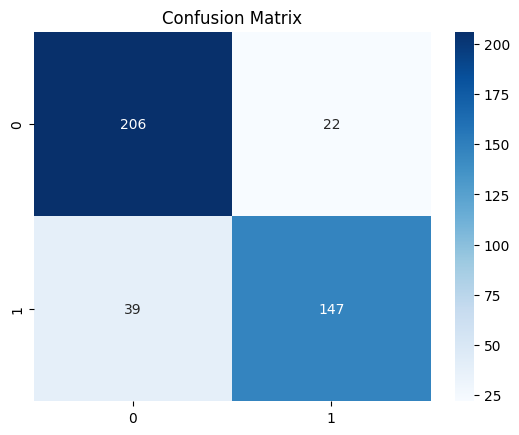

Macro F1: 0.8496024774439448


In [10]:
y_pred = (final_model.predict(X_test_vec) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


In [11]:
# === Inference Time Benchmark (selaras dengan BERT) ===
import time
benchmark_size = min(32, len(X_test_vec))
subset = X_test_vec[:benchmark_size]

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset, verbose=0)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset, verbose=0)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")


🕒 Avg batch inference time: 0.060042009353637696
📊 Throughput: 532.9601781233735 samples/sec
